In [1]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")

print(train.shape)
print(test.shape)

(668665, 15)
(286571, 14)


In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [3]:
print(train["Will_Buy_EV"].value_counts())

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


In [4]:
print(train["Will_Buy_EV"].value_counts(normalize=True))

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


In [5]:
pd.crosstab(
    train["Home_Charging_Possible"],
    train["Will_Buy_EV"],
    normalize="index"
)

Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,0.872915,0.127085
Yes,0.804181,0.195819


In [6]:
pd.crosstab(
    train["Subsidy_Available"],
    train["Will_Buy_EV"],
    normalize="index"
)

Will_Buy_EV,No,Yes
Subsidy_Available,,
No,0.994243,0.005757
Yes,0.725305,0.274695


In [7]:
pd.crosstab(
    train["Range_Anxiety_Level"],
    train["Will_Buy_EV"],
    normalize="index"
)

Will_Buy_EV,No,Yes
Range_Anxiety_Level,,
High,0.998633,0.001367
Low,0.810973,0.189027
Medium,0.958255,0.041745


In [8]:
train.groupby("Will_Buy_EV")["Age"].mean()

Will_Buy_EV
No     47.083293
Yes    46.830654
Name: Age, dtype: float64

In [9]:
train.groupby("Will_Buy_EV")["Annual_Income_USD"].mean()

Will_Buy_EV
No     81794.588556
Yes    98827.302948
Name: Annual_Income_USD, dtype: float64

In [10]:
train.groupby("Will_Buy_EV")["Annual_Income_USD"].describe()

,count,mean,std,min,25%,50%,75%,max
Will_Buy_EV,,,,,,,,
No,551886.0,81794.588556,28237.155138,30000.0,64387.0,82844.0,97655.0,169972.0
Yes,116779.0,98827.302948,26300.675910,30000.0,81899.0,96167.0,116987.0,188549.0


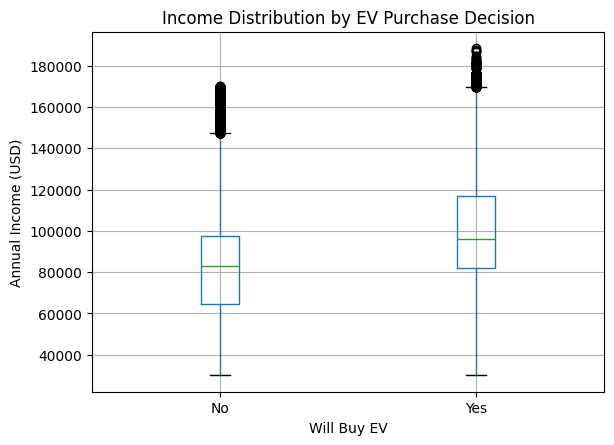

In [11]:
import matplotlib.pyplot as plt

train.boxplot(
    column="Annual_Income_USD",
    by="Will_Buy_EV"
)

plt.title("Income Distribution by EV Purchase Decision")
plt.suptitle("")
plt.xlabel("Will Buy EV")
plt.ylabel("Annual Income (USD)")
plt.show()

In [12]:
pd.crosstab(
    train["Current_Car_Type"],
    train["Will_Buy_EV"],
    normalize="index"
)

Will_Buy_EV,No,Yes
Current_Car_Type,,
Hatchback,0.825701,0.174299
SUV,0.819047,0.180953
Sedan,0.828033,0.171967
Truck,0.843587,0.156413


In [13]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["Will_Buy_EV"])
y = train["Will_Buy_EV"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(534932, 14)
(133733, 14)
(534932,)
(133733,)


In [14]:

numerical_features = [
    'Age', 
    'Annual_Income_USD', 
    'Daily_Commute_km', 
    'Number_of_Cars_Owned', 
    'Charging_Stations_Near_Home', 
    'Charging_Stations_Near_Work', 
    'Environmental_Concern_Level'
]

categorical_features = [
    'Gender', 
    'City_Type', 
    'Current_Car_Type', 
    'Home_Charging_Possible', 
    'Subsidy_Available', 
    'Range_Anxiety_Level'
]


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Model created successfully!")

Model created successfully!


In [16]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income_USD',
                                                   'Daily_Commute_km',
                                                   'Number_of_Cars_Owned',
                                                   'Charging_Stations_Near_Home',
                                                   'Charging_Stations_Near_Work',
                                                   'Environmental_Concern_Level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'City_Type',
                                                   'Current_Car_Type',
                                                   'Home_Charging_Possible',
                                                   'Subsidy_Available',
                                                   'Range_Anxiety_Level'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [17]:
valid_proba = model.predict_proba(X_valid)[:, 1]

print(valid_proba[:10])

[4.47958859e-02 4.88649122e-02 7.55830202e-01 1.51677863e-03
 5.04111122e-03 2.87150180e-04 8.75725763e-03 8.12131712e-03
 5.48759136e-01 3.03067546e-01]


In [18]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_valid, valid_proba)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.9379578769118007


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

numerical_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Tree preprocessor created!")

Tree preprocessor created!


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            random_state=42
        ))
    ]
)

print("Decision Tree created!")

Decision Tree created!


In [21]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["Will_Buy_EV"])
y = train["Will_Buy_EV"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (534932, 14)
X_valid: (133733, 14)
y_train: (534932,)
y_valid: (133733,)


In [22]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Annual_Income_USD',
                                                   'Daily_Commute_km',
                                                   'Number_of_Cars_Owned',
                                                   'Charging_Stations_Near_Home',
                                                   'Charging_Stations_Near_Work',
                                                   'Environmental_Concern_Level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'City_Type',
                                                   'Current_Car_Type',
                                                   'Home_Charging_Possible',
                                                   'Subsidy_Available',
                                                   'Range_Anxiety_Level'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=6, random_state=42))])

In [23]:
tree_valid_proba = tree_model.predict_proba(X_valid)[:, 1]

print(tree_valid_proba[:10])

[5.96286063e-02 2.56485849e-02 7.37512473e-01 2.24517288e-03
 7.36340573e-03 1.09900174e-04 6.58407211e-03 6.58407211e-03
 6.45916300e-01 3.48267581e-01]


In [24]:
from sklearn.metrics import roc_auc_score

tree_auc = roc_auc_score(y_valid, tree_valid_proba)

print("Decision Tree Validation ROC-AUC:", tree_auc)

Decision Tree Validation ROC-AUC: 0.9367618355588578


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

depths = [3, 5, 7, 10, 15, 20]

results = []

for depth in depths:
    
    tree_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("classifier", DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            ))
        ]
    )
    
    tree_model.fit(X_train, y_train)
    
    valid_proba = tree_model.predict_proba(X_valid)[:, 1]
    
    auc = roc_auc_score(y_valid, valid_proba)
    
    results.append((depth, auc))
    
    print(f"Depth {depth}: ROC-AUC = {auc:.6f}")

Depth 3: ROC-AUC = 0.906737
Depth 5: ROC-AUC = 0.932946
Depth 7: ROC-AUC = 0.938076
Depth 10: ROC-AUC = 0.938265
Depth 15: ROC-AUC = 0.918849
Depth 20: ROC-AUC = 0.861762


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

depths = [3, 5, 7, 10, 15, 20]

results = []

for depth in depths:

    tree_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("classifier", DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            ))
        ]
    )

    tree_model.fit(X_train, y_train)

    # Training predictions
    train_proba = tree_model.predict_proba(X_train)[:, 1]

    # Validation predictions
    valid_proba = tree_model.predict_proba(X_valid)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    valid_auc = roc_auc_score(y_valid, valid_proba)

    results.append((depth, train_auc, valid_auc))

    print(
        f"Depth {depth}: "
        f"Train AUC = {train_auc:.6f}, "
        f"Validation AUC = {valid_auc:.6f}"
    )

Depth 3: Train AUC = 0.906092, Validation AUC = 0.906737
Depth 5: Train AUC = 0.933026, Validation AUC = 0.932946
Depth 7: Train AUC = 0.938923, Validation AUC = 0.938076
Depth 10: Train AUC = 0.942414, Validation AUC = 0.938265
Depth 15: Train AUC = 0.954612, Validation AUC = 0.918849
Depth 20: Train AUC = 0.978194, Validation AUC = 0.861762


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

rf_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_valid_proba = rf_model.predict_proba(X_valid)[:, 1]

rf_auc = roc_auc_score(y_valid, rf_valid_proba)

print("Random Forest Validation ROC-AUC:", rf_auc)

Random Forest Validation ROC-AUC: 0.9350157470239749


In [28]:
depths = [5, 7, 10, 15, 20]

for depth in depths:

    rf_model = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                random_state=42,
                n_jobs=-1
            ))
        ]
    )

    rf_model.fit(X_train, y_train)

    rf_valid_proba = rf_model.predict_proba(X_valid)[:, 1]

    rf_auc = roc_auc_score(y_valid, rf_valid_proba)

    print(f"Depth {depth}: ROC-AUC = {rf_auc:.6f}")

Depth 5: ROC-AUC = 0.926977
Depth 7: ROC-AUC = 0.930248
Depth 10: ROC-AUC = 0.935016
Depth 15: ROC-AUC = 0.937288
Depth 20: ROC-AUC = 0.936650


In [29]:
import importlib.util

print("XGBoost:", importlib.util.find_spec("xgboost") is not None)
print("LightGBM:", importlib.util.find_spec("lightgbm") is not None)
print("CatBoost:", importlib.util.find_spec("catboost") is not None)

XGBoost: True
LightGBM: True
CatBoost: True


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numerical_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

categorical_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

xgb_preprocessor = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [31]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            eval_metric="auc"
        ))
    ]
)
print("Model created successfully!")

Model created successfully!


In [32]:
y_train_xgb = y_train.map({
    "No": 0,
    "Yes": 1
})

y_valid_xgb = y_valid.map({
    "No": 0,
    "Yes": 1
})
print(y_train_xgb.value_counts())
print(y_valid_xgb.value_counts())

Will_Buy_EV
0    441509
1     93423
Name: count, dtype: int64
Will_Buy_EV
0    110377
1     23356
Name: count, dtype: int64
